Theta cyclical encoding:
  Original theta range: [-1.7135, 71.2563] rad
  Theta wraps at 2π, so we encode it cyclically
  X_raw shape: (7932, 2) (for models with feature engineering)
  X_cyclical shape: (7932, 3) (for models using raw features)

Data splits:
  X_train_raw shape: (6345, 2)
  X_train_cyclical shape: (6345, 3)
  y_train shape: (6345,)
  X_test_raw shape: (1587, 2)
  X_test_cyclical shape: (1587, 3)
  y_test shape: (1587,)

Data Statistics:
  Theta range: [-1.7135, 71.2563] rad
  Omega range: [-340.0542, 915.6376] rad/s
  F_hat range: [-8.21e-08, 1.00e-06]
  F_hat mean: 6.52e-07, std: 3.00e-07

Signal Analysis:
  F_hat variance: 9.02e-14
  F_hat std/mean ratio: 0.46
  Coefficient of variation: 0.46

Correlation Analysis:
  F_hat vs sin(theta): 0.0354
  F_hat vs cos(theta): 0.1437
  F_hat vs omega: 0.7403
  F_hat vs omega^2: 0.6320
  F_hat vs |omega|: 0.7409


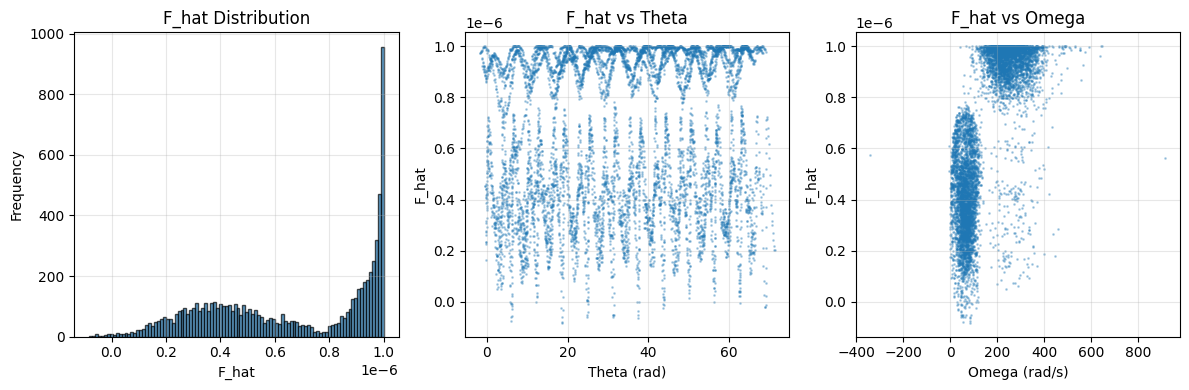

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Load the processed data
data = np.load('processed_data_smooth.npz')
thetas = data['thetas']
omegas = data['omegas']
F_hat = data['F_hat']

# IMPORTANT: Theta is cyclical (wrapped at 2π), so we need to encode it properly
# We'll create both raw and encoded versions for different models
def encode_theta_cyclical(theta):
    """
    Encode theta in a cyclical way using sin and cos.
    This ensures that 0 and 2π are treated as the same.
    """
    return np.column_stack([np.sin(theta), np.cos(theta)])

# Create feature matrices:
# - X_raw: for models that do their own feature engineering (like Ridge)
# - X_cyclical: for models that use raw features directly (like NN)
X_raw = np.column_stack([thetas, omegas])  # [theta, omega] - for feature engineering
theta_encoded = encode_theta_cyclical(thetas)
X_cyclical = np.column_stack([theta_encoded, omegas])  # [sin(theta), cos(theta), omega] - for direct use
y = F_hat

print("Theta cyclical encoding:")
print(f"  Original theta range: [{thetas.min():.4f}, {thetas.max():.4f}] rad")
print(f"  Theta wraps at 2π, so we encode it cyclically")
print(f"  X_raw shape: {X_raw.shape} (for models with feature engineering)")
print(f"  X_cyclical shape: {X_cyclical.shape} (for models using raw features)")

# Split the data into training and testing sets
# Use raw features for models that do feature engineering
X_train_raw, X_test_raw, y_train, y_test = train_test_split(X_raw, y, test_size=0.2, random_state=42)
# Use cyclical encoding for models that use raw features directly
X_train_cyclical, X_test_cyclical, _, _ = train_test_split(X_cyclical, y, test_size=0.2, random_state=42)

print(f"\nData splits:")
print(f"  X_train_raw shape: {X_train_raw.shape}")
print(f"  X_train_cyclical shape: {X_train_cyclical.shape}")
print(f"  y_train shape: {y_train.shape}")
print(f"  X_test_raw shape: {X_test_raw.shape}")
print(f"  X_test_cyclical shape: {X_test_cyclical.shape}")
print(f"  y_test shape: {y_test.shape}")

# Diagnostic: Check the scale of the data
print(f"\nData Statistics:")
print(f"  Theta range: [{thetas.min():.4f}, {thetas.max():.4f}] rad")
print(f"  Omega range: [{omegas.min():.4f}, {omegas.max():.4f}] rad/s")
print(f"  F_hat range: [{F_hat.min():.2e}, {F_hat.max():.2e}]")
print(f"  F_hat mean: {F_hat.mean():.2e}, std: {F_hat.std():.2e}")

# Check signal-to-noise: what's the variance we're trying to explain?
print(f"\nSignal Analysis:")
print(f"  F_hat variance: {F_hat.var():.2e}")
print(f"  F_hat std/mean ratio: {F_hat.std()/abs(F_hat.mean()) if F_hat.mean() != 0 else 'inf':.2f}")
print(f"  Coefficient of variation: {F_hat.std()/abs(F_hat.mean()) if F_hat.mean() != 0 else 'inf':.2f}")

# Check correlations with simple features
print(f"\nCorrelation Analysis:")
print(f"  F_hat vs sin(theta): {np.corrcoef(F_hat, np.sin(thetas))[0,1]:.4f}")
print(f"  F_hat vs cos(theta): {np.corrcoef(F_hat, np.cos(thetas))[0,1]:.4f}")
print(f"  F_hat vs omega: {np.corrcoef(F_hat, omegas)[0,1]:.4f}")
print(f"  F_hat vs omega^2: {np.corrcoef(F_hat, omegas**2)[0,1]:.4f}")
print(f"  F_hat vs |omega|: {np.corrcoef(F_hat, np.abs(omegas))[0,1]:.4f}")

# Visualize F_hat distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.hist(F_hat, bins=100, alpha=0.7, edgecolor='black')
plt.xlabel('F_hat')
plt.ylabel('Frequency')
plt.title('F_hat Distribution')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
plt.scatter(thetas, F_hat, alpha=0.3, s=1)
plt.xlabel('Theta (rad)')
plt.ylabel('F_hat')
plt.title('F_hat vs Theta')
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 3)
plt.scatter(omegas, F_hat, alpha=0.3, s=1)
plt.xlabel('Omega (rad/s)')
plt.ylabel('F_hat')
plt.title('F_hat vs Omega')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



In [13]:
# Print the full equation for the ridge model, using coefficients, scaling, and feature definitions.
print("\n" + "="*40)
print("Full Ridge Regression Model Equation")
print("="*40)

# 1. Print feature formula
print("Feature transformations:")
print("  x1 = sin(theta)")
print("  x2 = cos(theta)")
print("  x3 = sin(2*theta)")
print("  x4 = cos(2*theta)")
print("  x5 = omega")
print("  x6 = omega^2")
print("  x7 = omega^3")
print("  x8 = sign(omega)")
print("  x9  = omega * sin(theta)")
print("  x10 = omega * cos(theta)")
print("  x11 = |omega| * sin(theta)")
print("  x12 = |omega| * cos(theta)")

print("\nFeature scaling:")
for i, name in enumerate(feature_names):
    mu = feature_scaler.mean_[i]
    sigma = feature_scaler.scale_[i]
    print(f"  {name:19s}: (x{i+1} - {mu:.4g}) / {sigma:.4g}")
    
print(f"\nThe predicted output for a raw datapoint (theta, omega) is:")
print("  features = [x1, x2, ..., x12] as above")
print("  scaled_features = (features - mean) / std (per above)")
print("Then:")
print("  F_hat = intercept", end="")
for i, (name, coef) in enumerate(zip(feature_names, ridge_model.coef_)):
    if coef != 0.0:
        print(f" + ({coef:.4e}) * scaled_{name}", end="")
print()

print("="*40)
print("\nTo evaluate for new (theta, omega),")
print("1. Calculate each feature x_i as above")
print("2. Scale: (x_i - mean)/std (means/std shown above, from training set)")
print("3. Multiply by corresponding coefficient and sum (add intercept)")
print("This gives the model's prediction for F_hat.")



Full Ridge Regression Model Equation
Feature transformations:
  x1 = sin(theta)
  x2 = cos(theta)
  x3 = sin(2*theta)
  x4 = cos(2*theta)
  x5 = omega
  x6 = omega^2
  x7 = omega^3
  x8 = sign(omega)
  x9  = omega * sin(theta)
  x10 = omega * cos(theta)
  x11 = |omega| * sin(theta)
  x12 = |omega| * cos(theta)

Feature scaling:
  sin(theta)         : (x1 - -0.01524) / 0.6765
  cos(theta)         : (x2 - 0.03287) / 0.7356
  sin(2*theta)       : (x3 - 0.01497) / 0.697
  cos(2*theta)       : (x4 - 0.08434) / 0.7119
  omega              : (x5 - 157.6) / 108.9
  omega^2            : (x6 - 3.671e+04) / 4.307e+04
  omega^3            : (x7 - 1.024e+07) / 1.881e+07
  sign(omega)        : (x8 - 0.9981) / 0.06147
  omega*sin(theta)   : (x9 - -1.689) / 135.6
  omega*cos(theta)   : (x10 - 1.597) / 135.3
  |omega|*sin(theta) : (x11 - -1.688) / 135.6
  |omega|*cos(theta) : (x12 - 1.601) / 135.3

The predicted output for a raw datapoint (theta, omega) is:
  features = [x1, x2, ..., x12] as above
  s

In [2]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

# Model 1: Interpretable Polynomial/Sinusoidal Fit

def feature_transform(X):
    """
    Engineers features from the raw (theta, omega) data.
    Includes interaction terms for position-velocity dependent friction.
    """
    thetas = X[:, 0]
    omegas = X[:, 1]
    
    features = [
        np.sin(thetas),
        np.cos(thetas),
        np.sin(2 * thetas),
        np.cos(2 * thetas),
        omegas,
        omegas**2,
        omegas**3,
        np.sign(omegas),
        # Interaction terms for position-velocity dependent friction
        omegas * np.sin(thetas),
        omegas * np.cos(thetas),
        np.abs(omegas) * np.sin(thetas),
        np.abs(omegas) * np.cos(thetas),
    ]
    
    return np.vstack(features).T

feature_names = [
    'sin(theta)', 'cos(theta)', 'sin(2*theta)', 'cos(2*theta)', 
    'omega', 'omega^2', 'omega^3', 'sign(omega)',
    'omega*sin(theta)', 'omega*cos(theta)',
    '|omega|*sin(theta)', '|omega|*cos(theta)'
]

# Transform the data (using raw theta since feature_transform does its own sin/cos)
X_train_featured = feature_transform(X_train_raw)
X_test_featured = feature_transform(X_test_raw)

# Scale the features to avoid numerical issues
feature_scaler = StandardScaler()
X_train_featured_scaled = feature_scaler.fit_transform(X_train_featured)
X_test_featured_scaled = feature_scaler.transform(X_test_featured)

# Initialize and train the Ridge regression model
# Use a smaller alpha since we're scaling features now
ridge_model = Ridge(alpha=0.1)
ridge_model.fit(X_train_featured_scaled, y_train)

# Make predictions on the test set
y_pred_ridge = ridge_model.predict(X_test_featured_scaled)

# Evaluate the model
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
r2_ridge = r2_score(y_test, y_pred_ridge)

print(f"Ridge Model Performance:")
print(f"  MSE: {mse_ridge:.2e}")
print(f"  RMSE: {rmse_ridge:.2e}")
print(f"  R²: {r2_ridge:.4f}")
print(f"  Mean absolute error: {np.mean(np.abs(y_test - y_pred_ridge)):.2e}")

# Print the learned coefficients (in original feature space)
print("\nLearned Coefficients (top 5 by magnitude):")
coef_magnitudes = np.abs(ridge_model.coef_)
top_indices = np.argsort(coef_magnitudes)[::-1][:5]
for idx in top_indices:
    print(f"  {feature_names[idx]}: {ridge_model.coef_[idx]:.2e}")



Ridge Model Performance:
  MSE: 3.65e-14
  RMSE: 1.91e-07
  R²: 0.6007
  Mean absolute error: 1.34e-07

Learned Coefficients (top 5 by magnitude):
  omega: 4.82e-07
  omega^2: -3.01e-07
  omega*cos(theta): -9.64e-08
  |omega|*cos(theta): 8.50e-08
  cos(theta): 5.73e-08



NN with ONLY [sin(theta), cos(theta), omega] (CosineAnnealingWarmRestarts, No Norm!)

Starting training with ONLY sin(theta), cos(theta), omega (NO normalization)!
Epoch [20/300], Train Loss: 1.771e-01, Val Loss: 1.685e-01
Epoch [40/300], Train Loss: 1.689e-01, Val Loss: 1.633e-01
Epoch [60/300], Train Loss: 1.622e-01, Val Loss: 1.591e-01
Epoch [80/300], Train Loss: 1.654e-01, Val Loss: 1.591e-01
Epoch [100/300], Train Loss: 1.622e-01, Val Loss: 1.594e-01
Epoch [120/300], Train Loss: 1.590e-01, Val Loss: 1.566e-01
Epoch [140/300], Train Loss: 1.565e-01, Val Loss: 1.564e-01
Epoch [160/300], Train Loss: 1.625e-01, Val Loss: 1.602e-01
Epoch [180/300], Train Loss: 1.621e-01, Val Loss: 1.569e-01
Epoch [200/300], Train Loss: 1.591e-01, Val Loss: 1.571e-01
Epoch [220/300], Train Loss: 1.569e-01, Val Loss: 1.571e-01
Epoch [240/300], Train Loss: 1.552e-01, Val Loss: 1.574e-01
Epoch [260/300], Train Loss: 1.541e-01, Val Loss: 1.567e-01
Epoch [280/300], Train Loss: 1.538e-01, Val Loss: 1.555e-01

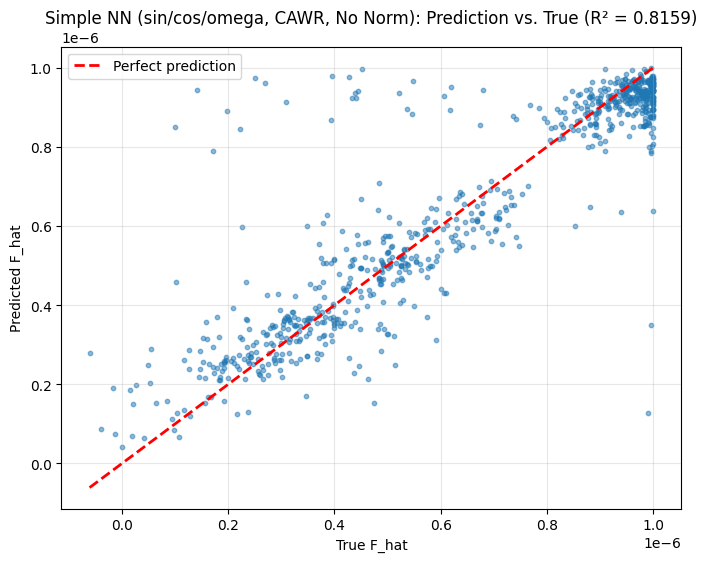

In [28]:
# Model 2-C: Simple Neural Network, only [sin(theta), cos(theta), omega], batched and without layer normalization

print("\n" + "="*50)
print("NN with ONLY [sin(theta), cos(theta), omega] (CosineAnnealingWarmRestarts, No Norm!)")
print("="*50)

# We'll just use sin(theta), cos(theta), and omega -- that's 3 input dims, not 12.
# Assume X_raw shape (...,2) is [theta, omega]
def cyclical_features(X):
    # X = [theta, omega]
    theta, omega = X[:,0], X[:,1]
    feats = np.stack([np.sin(theta), np.cos(theta), omega], axis=1)
    return feats

X_cyc = cyclical_features(X_raw)

# 80/10/10 split: train/val/test
X_train_val_cyc, X_test_cyc, y_train_val, y_test = train_test_split(
    X_cyc, y, test_size=0.1, random_state=42
)
X_train_cyc, X_val_cyc, y_train, y_val = train_test_split(
    X_train_val_cyc, y_train_val, test_size=0.111, random_state=42
)

# Standard scaling
X_scaler_cyc = StandardScaler()
X_train_scaled = X_scaler_cyc.fit_transform(X_train_cyc)
X_val_scaled = X_scaler_cyc.transform(X_val_cyc)
X_test_scaled = X_scaler_cyc.transform(X_test_cyc)

y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
y_val_scaled = y_scaler.transform(y_val.reshape(-1, 1)).flatten()
y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1)).flatten()

# Tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32).view(-1, 1)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val_scaled, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32).view(-1, 1)

# DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)

# Define the network with input_dim=3, NO normalization (no batchnorm/layernorm)
class SimpleNN(nn.Module):
    def __init__(self, input_dim=3, hidden_dims=[256, 256, 256]):
        super().__init__()
        layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.ReLU())
            prev_dim = hidden_dim
        layers.append(nn.Linear(prev_dim, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

simple_nn = SimpleNN()

criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(simple_nn.parameters(), lr=3e-4, weight_decay=1e-4)
cawr_scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=20, T_mult=2)

num_epochs = 300
train_losses, val_losses = [], []
print("\nStarting training with ONLY sin(theta), cos(theta), omega (NO normalization)!")

for epoch in range(num_epochs):
    simple_nn.train()
    train_loss = 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = simple_nn(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_losses.append(train_loss / len(train_loader))

    simple_nn.eval()
    val_loss = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            outputs = simple_nn(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
    avg_val_loss = val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    cawr_scheduler.step(epoch + avg_val_loss/np.max(val_losses) if len(val_losses) > 0 and np.max(val_losses) > 0 else epoch)

    if (epoch + 1) % 20 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_losses[-1]:.3e}, Val Loss: {val_losses[-1]:.3e}')

# Evaluation after training
simple_nn.eval()
with torch.no_grad():
    y_pred_simple_nn_scaled = simple_nn(X_test_tensor)
    y_pred_simple_nn = y_scaler.inverse_transform(y_pred_simple_nn_scaled.numpy()).flatten()
    mse_simple_nn = mean_squared_error(y_test, y_pred_simple_nn)
    r2_simple_nn = r2_score(y_test, y_pred_simple_nn)

print(f"\nSimple NN (sin/cos/omega) Performance (CAWR, No Norm):")
print(f"  MSE: {mse_simple_nn:.2e}")
print(f"  RMSE: {np.sqrt(mse_simple_nn):.2e}")
print(f"  R²: {r2_simple_nn:.4f}")

if 'r2_adv_nn' in locals():
    print(f"\nComparison:")
    print(f"  Advanced NN R²: {r2_adv_nn:.4f}")
    print(f"  Simple (sin/cos/omega) NN R²: {r2_simple_nn:.4f}")

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_simple_nn, alpha=0.5, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red', lw=2, label='Perfect prediction')
plt.title(f'Simple NN (sin/cos/omega, CAWR, No Norm): Prediction vs. True (R² = {r2_simple_nn:.4f})')
plt.xlabel('True F_hat')
plt.ylabel('Predicted F_hat')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


Epoch [10/100], Loss: 2.13e-01
Epoch [20/100], Loss: 1.94e-01
Epoch [30/100], Loss: 1.89e-01
Epoch [40/100], Loss: 1.82e-01
Epoch [50/100], Loss: 1.82e-01
Epoch [60/100], Loss: 1.80e-01
Epoch [70/100], Loss: 1.77e-01
Epoch [80/100], Loss: 1.77e-01
Epoch [90/100], Loss: 1.74e-01
Epoch [100/100], Loss: 1.77e-01

Neural Network Model Performance:
  MSE: 1.67e-14
  RMSE: 1.29e-07
  R²: 0.8171
  Mean absolute error: 7.85e-08


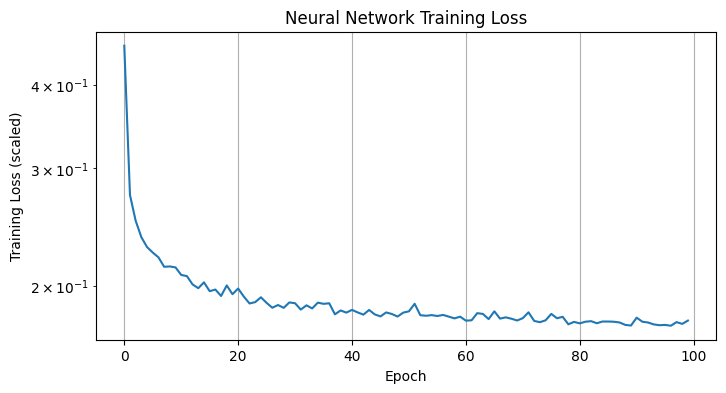

In [4]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

# Model 2: Simple Neural Network

# Scale the features (using cyclical encoding for NN)
X_scaler = StandardScaler()
X_train_scaled = X_scaler.fit_transform(X_train_cyclical)
X_test_scaled = X_scaler.transform(X_test_cyclical)

# Scale the target to help with training stability
# We'll unscale predictions later
y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = y_scaler.transform(y_test.reshape(-1, 1)).flatten()

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train_scaled, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test_scaled, dtype=torch.float32).view(-1, 1)

# Create TensorDatasets and DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Define the neural network model
# Note: input_dim=3 because we use [sin(theta), cos(theta), omega]
class SimpleNN(nn.Module):
    def __init__(self, input_dim=3, hidden_dims=[64, 64, 32]):
        super(SimpleNN, self).__init__()
        layers = []
        prev_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.1))  # Small dropout for regularization
            prev_dim = hidden_dim
        layers.append(nn.Linear(prev_dim, 1))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

nn_model = SimpleNN()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(nn_model.parameters(), lr=0.001, weight_decay=1e-5)

# Training the model
num_epochs = 100
train_losses = []
for epoch in range(num_epochs):
    epoch_loss = 0.0
    num_batches = 0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = nn_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        num_batches += 1
    
    avg_loss = epoch_loss / num_batches
    train_losses.append(avg_loss)
    
    # Print loss every 10 epochs with scientific notation
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.2e}')

# Evaluation
nn_model.eval()
with torch.no_grad():
    y_pred_nn_scaled = nn_model(X_test_tensor)
    # Unscale the predictions
    y_pred_nn = y_scaler.inverse_transform(y_pred_nn_scaled.numpy()).flatten()
    
    # Calculate metrics on original scale
    mse_nn = mean_squared_error(y_test, y_pred_nn)
    rmse_nn = np.sqrt(mse_nn)
    r2_nn = r2_score(y_test, y_pred_nn)

print(f"\nNeural Network Model Performance:")
print(f"  MSE: {mse_nn:.2e}")
print(f"  RMSE: {rmse_nn:.2e}")
print(f"  R²: {r2_nn:.4f}")
print(f"  Mean absolute error: {np.mean(np.abs(y_test - y_pred_nn)):.2e}")

# Plot training curve
plt.figure(figsize=(8, 4))
plt.plot(train_losses)
plt.xlabel('Epoch')
plt.ylabel('Training Loss (scaled)')
plt.title('Neural Network Training Loss')
plt.yscale('log')
plt.grid(True)
plt.show()




MODEL COMPARISON SUMMARY
Ridge Model:
  MSE:  3.65e-14
  RMSE: 1.91e-07
  R²:   0.6007

Neural Network Model:
  MSE:  1.67e-14
  RMSE: 1.29e-07
  R²:   0.8171

Improvement (NN vs Ridge):
  MSE ratio:  2.18x
  RMSE ratio: 1.48x


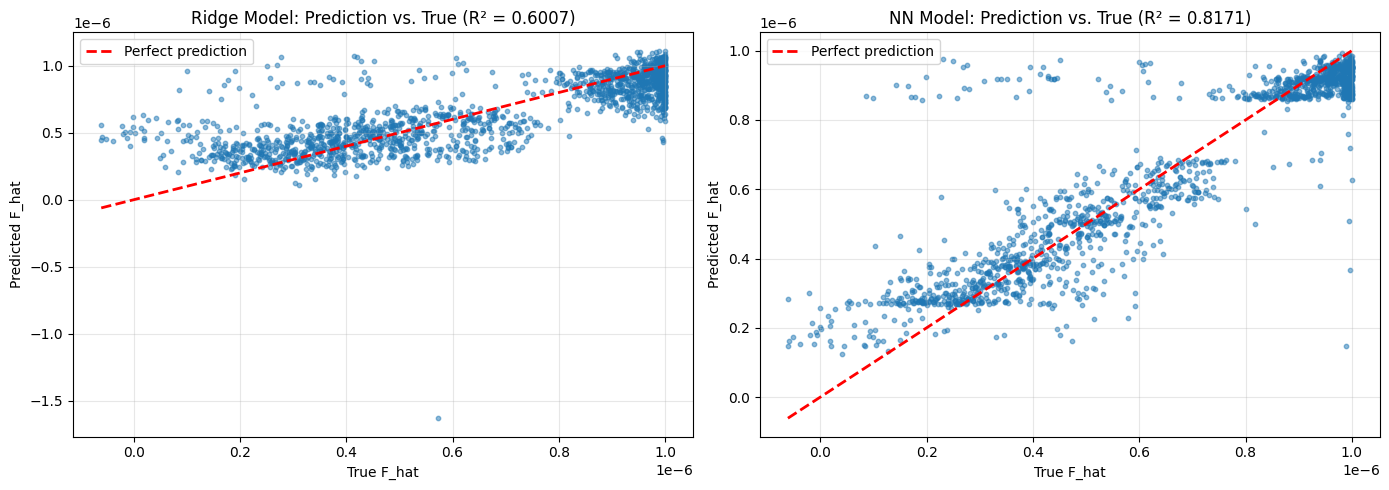

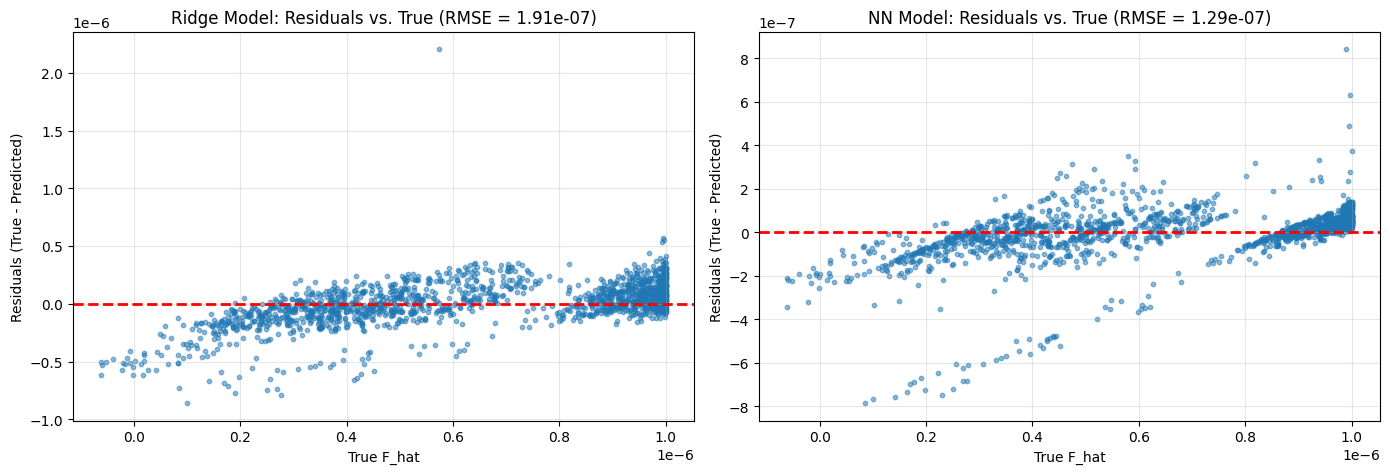

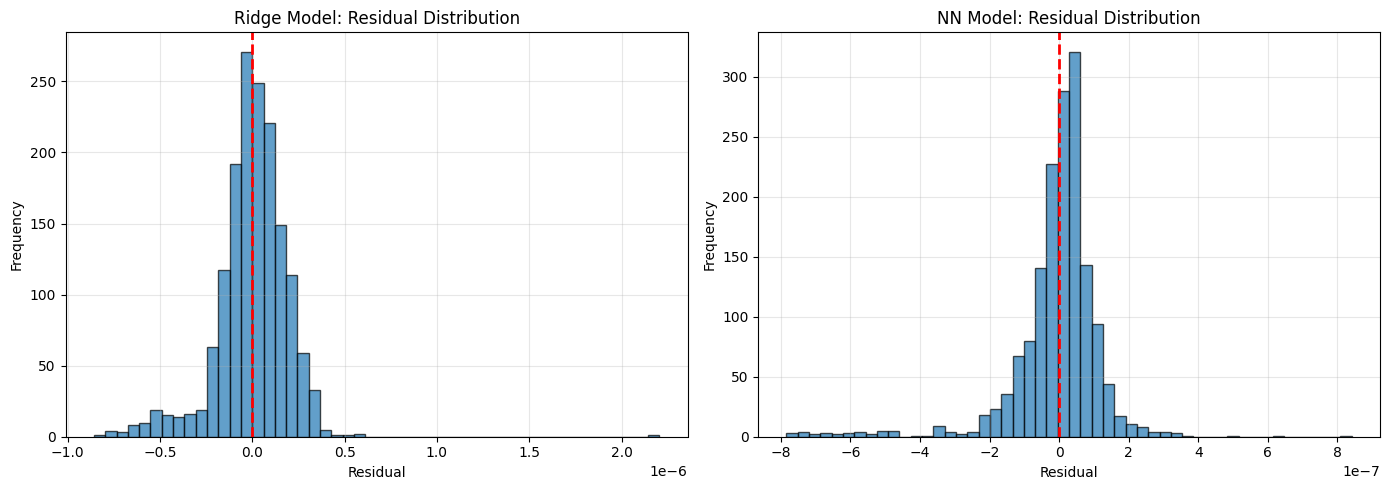

In [6]:
# Step 5: Compare the models

# Get the raw theta and omega from the original test set for plotting
thetas_test = X_test_raw[:, 0]
omegas_test = X_test_raw[:, 1]

# Print comparison summary
print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)
print(f"Ridge Model:")
print(f"  MSE:  {mse_ridge:.2e}")
print(f"  RMSE: {rmse_ridge:.2e}")
print(f"  R²:   {r2_ridge:.4f}")
print(f"\nNeural Network Model:")
print(f"  MSE:  {mse_nn:.2e}")
print(f"  RMSE: {rmse_nn:.2e}")
print(f"  R²:   {r2_nn:.4f}")
print(f"\nImprovement (NN vs Ridge):")
print(f"  MSE ratio:  {mse_ridge/mse_nn:.2f}x")
print(f"  RMSE ratio: {rmse_ridge/rmse_nn:.2f}x")
print("="*60)

# 1. Prediction vs. True Values
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_ridge, alpha=0.5, s=10)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red', lw=2, label='Perfect prediction')
axes[0].set_title(f'Ridge Model: Prediction vs. True (R² = {r2_ridge:.4f})')
axes[0].set_xlabel('True F_hat')
axes[0].set_ylabel('Predicted F_hat')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].scatter(y_test, y_pred_nn, alpha=0.5, s=10)
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red', lw=2, label='Perfect prediction')
axes[1].set_title(f'NN Model: Prediction vs. True (R² = {r2_nn:.4f})')
axes[1].set_xlabel('True F_hat')
axes[1].set_ylabel('Predicted F_hat')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

# 2. Residuals Plot
residuals_ridge = y_test - y_pred_ridge
residuals_nn = y_test - y_pred_nn

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, residuals_ridge, alpha=0.5, s=10)
axes[0].axhline(0, color='red', linestyle='--', lw=2)
axes[0].set_title(f'Ridge Model: Residuals vs. True (RMSE = {rmse_ridge:.2e})')
axes[0].set_xlabel('True F_hat')
axes[0].set_ylabel('Residuals (True - Predicted)')
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_test, residuals_nn, alpha=0.5, s=10)
axes[1].axhline(0, color='red', linestyle='--', lw=2)
axes[1].set_title(f'NN Model: Residuals vs. True (RMSE = {rmse_nn:.2e})')
axes[1].set_xlabel('True F_hat')
axes[1].set_ylabel('Residuals (True - Predicted)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 3. Distribution of residuals
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(residuals_ridge, bins=50, alpha=0.7, edgecolor='black')
axes[0].axvline(0, color='red', linestyle='--', lw=2)
axes[0].set_title(f'Ridge Model: Residual Distribution')
axes[0].set_xlabel('Residual')
axes[0].set_ylabel('Frequency')
axes[0].grid(True, alpha=0.3)

axes[1].hist(residuals_nn, bins=50, alpha=0.7, edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--', lw=2)
axes[1].set_title(f'NN Model: Residual Distribution')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 4. 3D Polar-like plot of predictions in state space (theta = angle, omega = radius)
try:
    import plotly.graph_objs as go
    from numpy import cos, sin

    # Convert to polar coordinates for all sets
    def to_cartesian(theta, omega):
        x = omega * np.cos(theta)
        y = omega * np.sin(theta)
        return x, y

    # True values
    x_true, y_true = to_cartesian(thetas_test, omegas_test)
    # Ridge predictions, same positions as test
    x_ridge, y_ridge = x_true, y_true
    # NN predictions, same positions as test
    x_nn, y_nn = x_true, y_true

    fig = go.Figure()

    # True data: z is y_test at (theta, omega)
    fig.add_trace(go.Scatter3d(
        x=x_true, y=y_true, z=y_test,
        mode='markers',
        marker=dict(size=2, color='blue', opacity=0.4),
        name='True Data'
    ))

    # Ridge predictions
    fig.add_trace(go.Scatter3d(
        x=x_ridge, y=y_ridge, z=y_pred_ridge,
        mode='markers',
        marker=dict(size=2, color='green', opacity=0.6),
        name='Ridge Predictions'
    ))

    # NN predictions
    fig.add_trace(go.Scatter3d(
        x=x_nn, y=y_nn, z=y_pred_nn,
        mode='markers',
        marker=dict(size=2, color='red', opacity=0.6),
        name='NN Predictions'
    ))

    fig.update_layout(
        title='Model Predictions in Polar State Space (theta=angle, omega=radius)',
        scene=dict(
            xaxis_title='omega*cos(theta)',
            yaxis_title='omega*sin(theta)',
            zaxis_title='F_hat'
        ),
        height=700
    )
    fig.show()
except ImportError:
    print("Plotly not available, skipping 3D polar plot")


Testing with very flexible models to see if there's any learnable pattern...

Random Forest:
  MSE: 1.68e-14
  R²: 0.8162


/home/sman/miniconda3/envs/py310/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning:

The optimal value found for dimension 0 of parameter k1__length_scale is close to the specified upper bound 100000.0. Increasing the bound and calling fit again may find a better value.

/home/sman/miniconda3/envs/py310/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:440: ConvergenceWarning:

The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.




Gaussian Process (on 1000 samples):
  MSE: 4.35e-14
  R²: 0.5237
  Learned kernel: RBF(length_scale=1e+05) + WhiteKernel(noise_level=1e-05)

ALL MODELS COMPARISON
Ridge:        R² = 0.6007, RMSE = 1.91e-07
Neural Net:   R² = 0.8171, RMSE = 1.29e-07
Random Forest: R² = 0.8162, RMSE = 1.30e-07
Gaussian Proc: R² = 0.5237, RMSE = 2.09e-07


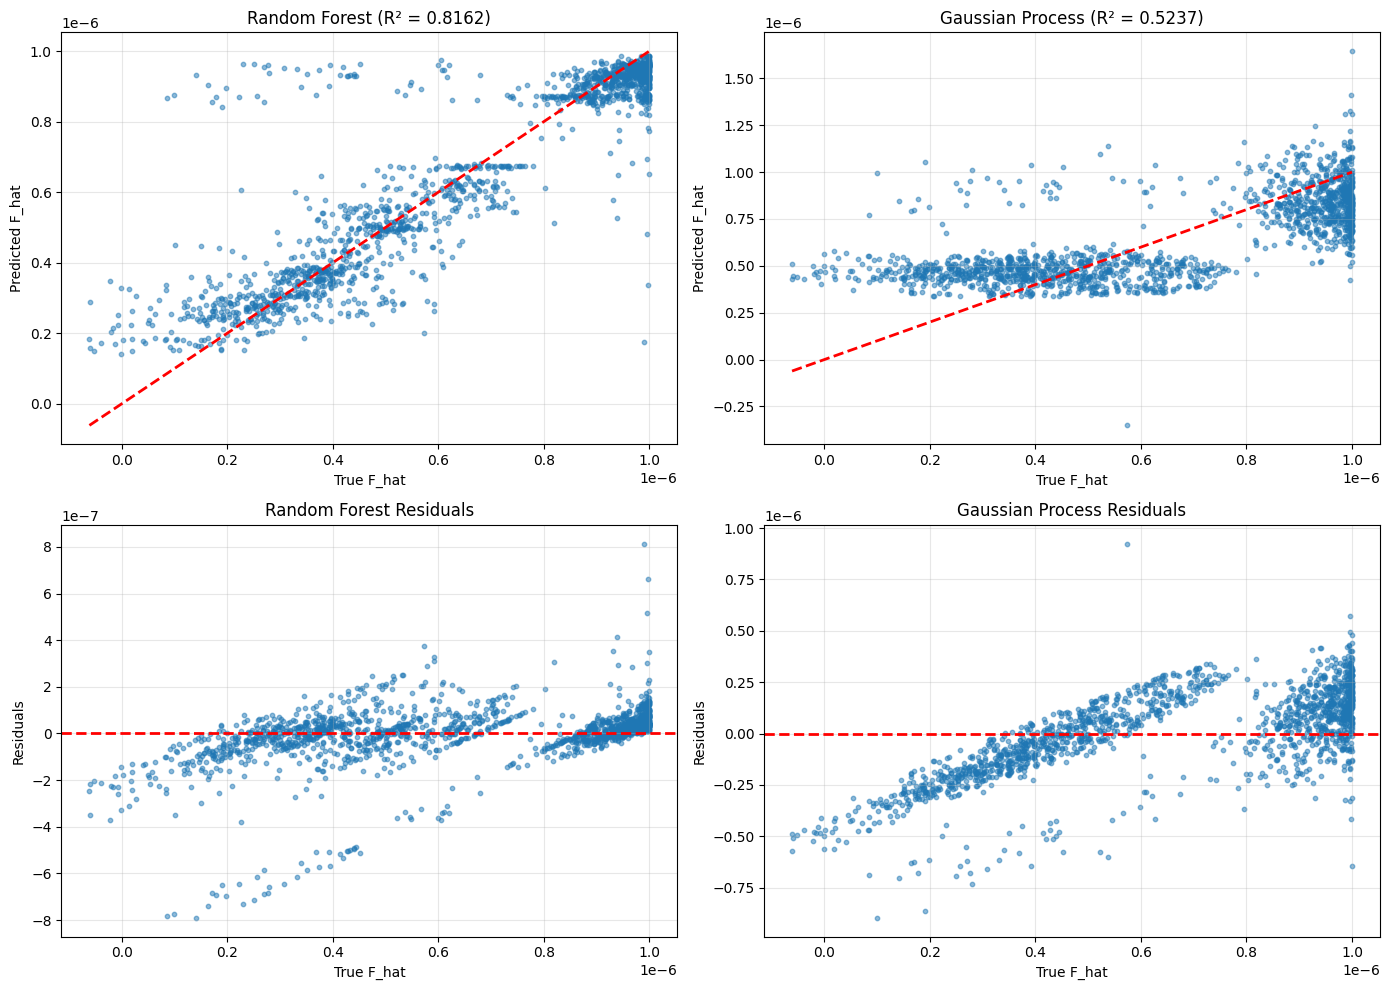


Random Forest Feature Importance:
  sin(theta): 0.0609
  cos(theta): 0.0963
  Omega: 0.8428
  (Note: theta is encoded cyclically as [sin(theta), cos(theta)])


In [7]:
# Deep dive: Is there actually a learnable pattern?
# Let's try a very flexible model to see if ANY pattern exists

from sklearn.ensemble import RandomForestRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, Matern

print("Testing with very flexible models to see if there's any learnable pattern...\n")

# Try Random Forest (very flexible, non-parametric)
# Use cyclical encoding for theta
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train_cyclical, y_train)
y_pred_rf = rf_model.predict(X_test_cyclical)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print(f"Random Forest:")
print(f"  MSE: {mse_rf:.2e}")
print(f"  R²: {r2_rf:.4f}")

# Try Gaussian Process with RBF kernel (can learn smooth functions)
# Use a subset for GP (it's computationally expensive)
# Use cyclical encoding for theta
n_gp = min(1000, len(X_train_cyclical))
indices = np.random.choice(len(X_train_cyclical), n_gp, replace=False)
X_train_gp = X_train_cyclical[indices]
y_train_gp = y_train[indices]

kernel = RBF(length_scale=1.0) + WhiteKernel(noise_level=1e-12)
gp_model = GaussianProcessRegressor(kernel=kernel, alpha=1e-10, n_restarts_optimizer=5, random_state=42)
gp_model.fit(X_train_gp, y_train_gp)
y_pred_gp, y_std_gp = gp_model.predict(X_test_cyclical, return_std=True)
mse_gp = mean_squared_error(y_test, y_pred_gp)
r2_gp = r2_score(y_test, y_pred_gp)
print(f"\nGaussian Process (on {n_gp} samples):")
print(f"  MSE: {mse_gp:.2e}")
print(f"  R²: {r2_gp:.4f}")
print(f"  Learned kernel: {gp_model.kernel_}")

# Compare all models
print("\n" + "="*60)
print("ALL MODELS COMPARISON")
print("="*60)
print(f"Ridge:        R² = {r2_ridge:.4f}, RMSE = {rmse_ridge:.2e}")
print(f"Neural Net:   R² = {r2_nn:.4f}, RMSE = {rmse_nn:.2e}")
print(f"Random Forest: R² = {r2_rf:.4f}, RMSE = {np.sqrt(mse_rf):.2e}")
print(f"Gaussian Proc: R² = {r2_gp:.4f}, RMSE = {np.sqrt(mse_gp):.2e}")
print("="*60)

# Visualize predictions from flexible models
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].scatter(y_test, y_pred_rf, alpha=0.5, s=10)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red', lw=2)
axes[0, 0].set_title(f'Random Forest (R² = {r2_rf:.4f})')
axes[0, 0].set_xlabel('True F_hat')
axes[0, 0].set_ylabel('Predicted F_hat')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].scatter(y_test, y_pred_gp, alpha=0.5, s=10)
axes[0, 1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--', color='red', lw=2)
axes[0, 1].set_title(f'Gaussian Process (R² = {r2_gp:.4f})')
axes[0, 1].set_xlabel('True F_hat')
axes[0, 1].set_ylabel('Predicted F_hat')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].scatter(y_test, y_test - y_pred_rf, alpha=0.5, s=10)
axes[1, 0].axhline(0, color='red', linestyle='--', lw=2)
axes[1, 0].set_title('Random Forest Residuals')
axes[1, 0].set_xlabel('True F_hat')
axes[1, 0].set_ylabel('Residuals')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].scatter(y_test, y_test - y_pred_gp, alpha=0.5, s=10)
axes[1, 1].axhline(0, color='red', linestyle='--', lw=2)
axes[1, 1].set_title('Gaussian Process Residuals')
axes[1, 1].set_xlabel('True F_hat')
axes[1, 1].set_ylabel('Residuals')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Feature importance from Random Forest
feature_importance = rf_model.feature_importances_
print(f"\nRandom Forest Feature Importance:")
print(f"  sin(theta): {feature_importance[0]:.4f}")
print(f"  cos(theta): {feature_importance[1]:.4f}")
print(f"  Omega: {feature_importance[2]:.4f}")
print(f"  (Note: theta is encoded cyclically as [sin(theta), cos(theta)])")
